In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

print("Train shape:", x_train.shape, "Test shape:", x_test.shape)

Train shape: (60000, 28, 28) Test shape: (10000, 28, 28)


In [6]:
y_train_oh = to_categorical(y_train, num_classes=10)
y_test_oh  = to_categorical(y_test, num_classes=10)

print("Labels one-hot:", y_train_oh.shape, y_test_oh.shape)

Labels one-hot: (60000, 10) (10000, 10)


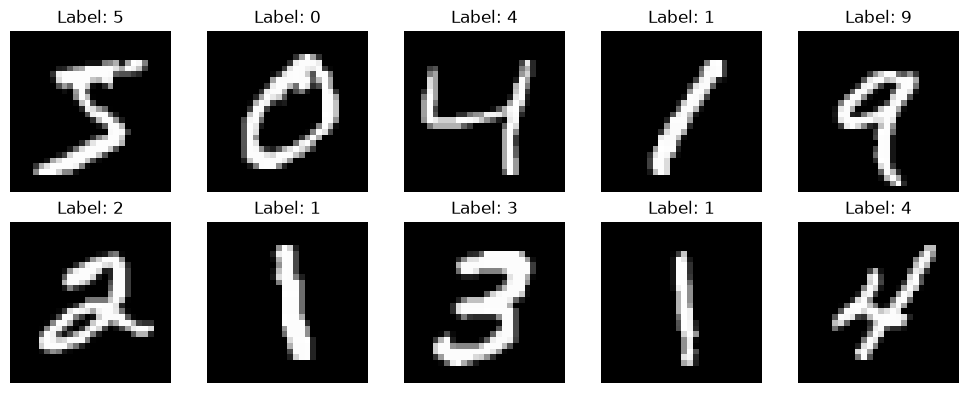

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap="gray")
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [8]:
model = models.Sequential([
    layers.Flatten(),
    layers.Dense(192, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax'),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(optimizer='adam', 
              loss=tf.losses.CategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [10]:
history = model.fit(
    x_train,
    y_train_oh,
    epochs=10,
    validation_data=(x_test, y_test_oh)
)
test_loss, test_acc = model.evaluate(x_test, y_test_oh)
print({"test_loss": float(test_loss), "test_acc": float(test_acc)})


Epoch 1/10


c:\Users\avigd\Desktop\GENAI\.venv2\Lib\site-packages\keras\src\backend\tensorflow\nn.py:1360: UserWarning: "`categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9366 - loss: 0.2154 - val_accuracy: 0.9603 - val_loss: 0.1220
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9720 - loss: 0.0891 - val_accuracy: 0.9730 - val_loss: 0.0804
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9810 - loss: 0.0608 - val_accuracy: 0.9744 - val_loss: 0.0807
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9853 - loss: 0.0454 - val_accuracy: 0.9775 - val_loss: 0.0795
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9879 - loss: 0.0365 - val_accuracy: 0.9777 - val_loss: 0.0780
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9900 - loss: 0.0302 - val_accuracy: 0.9760 - val_loss: 0.0933
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9914 - loss: 0.0248 - val_accuracy: 0.9802 - val_loss: 0.0813
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9928 - loss: 0.0213 - val_accurac

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 825us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9782 - loss: 0.0902
Test accuracy: 0.9782


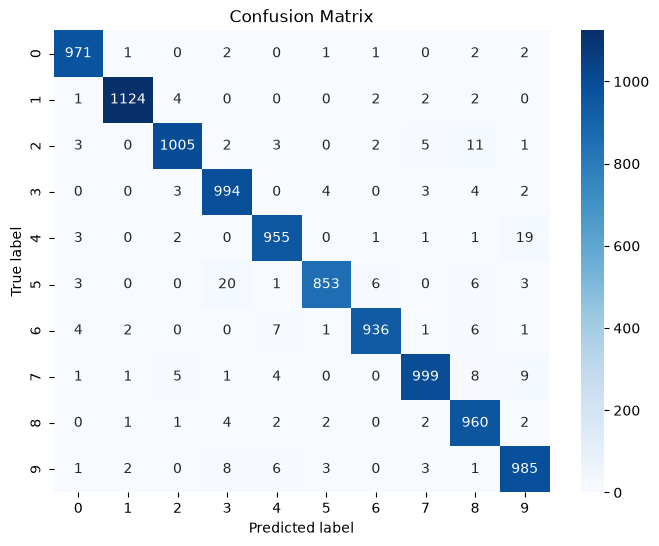

In [ ]:
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

test_loss, test_acc = model.evaluate(x_test, y_test_oh)
print(f"Test accuracy: {test_acc:.4f}")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")
plt.show()


In [17]:
per_digit_acc = cm.diagonal() / cm.sum(axis=1)
for digit, acc in enumerate(per_digit_acc):
    print(f"Digit {digit}: accuracy = {acc:.4f}")

worst_digits = np.argsort(per_digit_acc)[:3]
print("Digits the model struggles with most:", worst_digits.tolist())

print(classification_report(y_test, y_pred, digits=4))

Digit 0: accuracy = 0.9908
Digit 1: accuracy = 0.9903
Digit 2: accuracy = 0.9738
Digit 3: accuracy = 0.9842
Digit 4: accuracy = 0.9725
Digit 5: accuracy = 0.9563
Digit 6: accuracy = 0.9770
Digit 7: accuracy = 0.9718
Digit 8: accuracy = 0.9856
Digit 9: accuracy = 0.9762
Digits the model struggles with most: [5, 7, 4]
              precision    recall  f1-score   support

           0     0.9838    0.9908    0.9873       980
           1     0.9938    0.9903    0.9921      1135
           2     0.9853    0.9738    0.9795      1032
           3     0.9641    0.9842    0.9740      1010
           4     0.9765    0.9725    0.9745       982
           5     0.9873    0.9563    0.9715       892
           6     0.9873    0.9770    0.9822       958
           7     0.9833    0.9718    0.9775      1028
           8     0.9590    0.9856    0.9722       974
           9     0.9619    0.9762    0.9690      1009

    accuracy                         0.9782     10000
   macro avg     0.9782    0.977